In [143]:
import pandas as pd
import matplotlib.pyplot as plt

In [144]:
df = pd.read_csv('/Users/ASUS/Downloads/Finance_Parking_Fines_425930082550913200 (1).csv')


/var/folders/my/scqy6lj505v835sl0q7yr68m0000gn/T/ipykernel_82073/2081643779.py:1: DtypeWarning: Columns (0: ExpMM, 1: ExpYY, 2: InvestigationStatus, 3: Neighborhood, 4: PoliceDistrict, 5: Location) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/ASUS/Downloads/Finance_Parking_Fines_425930082550913200 (1).csv')


In [145]:
df.head()

,Citation,Tag,ExpMM,ExpYY,State,Make,Address,ViolCode,Description,ViolFine,...,GroupID,ImportDate,Neighborhood,PoliceDistrict,CouncilDistrict,Location,HashedRecord,NeedsSync,isDeleted,ESRI_OID
0,91,03W671,08,10,MD,FORD,O/S 1900 E EAGER ST,27,No Stop/Park Street Cleaning,52,...,Transportation Enforcement Officer,1/16/2022 4:52:00 PM,NaN,NaN,NaN,NaN,System.Byte[],0.0,0.0,1
1,166,T294093T,12,11,MD,JEEP,2300 E MONUMENT,12,No Stopping/Standing Not Tow-Away Zone,32,...,Transportation Enforcement Officer,1/16/2022 4:52:00 PM,NaN,NaN,NaN,NaN,System.Byte[],0.0,0.0,2
2,299,19TLR318,02,13,ME,NaN,900 LOW ST,99,All Other Stopping or Parking Violations,32,...,Transportation Enforcement Officer,1/16/2022 4:52:00 PM,NaN,NaN,NaN,NaN,System.Byte[],0.0,0.0,3
3,315,14TLR551,11,14,ME,NaN,1000 LOW ST,99,All Other Stopping or Parking Violations,32,...,Transportation Enforcement Officer,1/16/2022 4:52:00 PM,NaN,NaN,NaN,NaN,System.Byte[],0.0,0.0,4
4,562,9AE2340,03,13,MD,SUZU,LAFAYETTE MARKET LOT,18,All Other Parking Meter Violations,32,...,NaN,8/9/2013 4:03:00 AM,NaN,NaN,NaN,LAFAYETTE MARKET LOT Baltimore MD,System.Byte[],0.0,0.0,5


In [146]:
df.drop(['HashedRecord', 'NeedsSync', 'ESRI_OID', 'GroupID', 'ImportDate', 'Location', 'Address'], axis=1, inplace=True)

In [147]:
df['Make'].unique()

<StringArray>
[ 'FORD',  'JEEP',     nan,  'SUZU',  'CHEV',  'NISS', 'ACURA',  'VOLK',
  'DODG',  'CHRY',
 ...
  'KONA', 'SANTE', 'FAILU',  'CFHG', 'VENUE',  'LNCP',  'WHCH', '00813',
 'C&S/5', 'AIRST']
Length: 2422, dtype: str

Text(0.5, 0, 'Car Make')

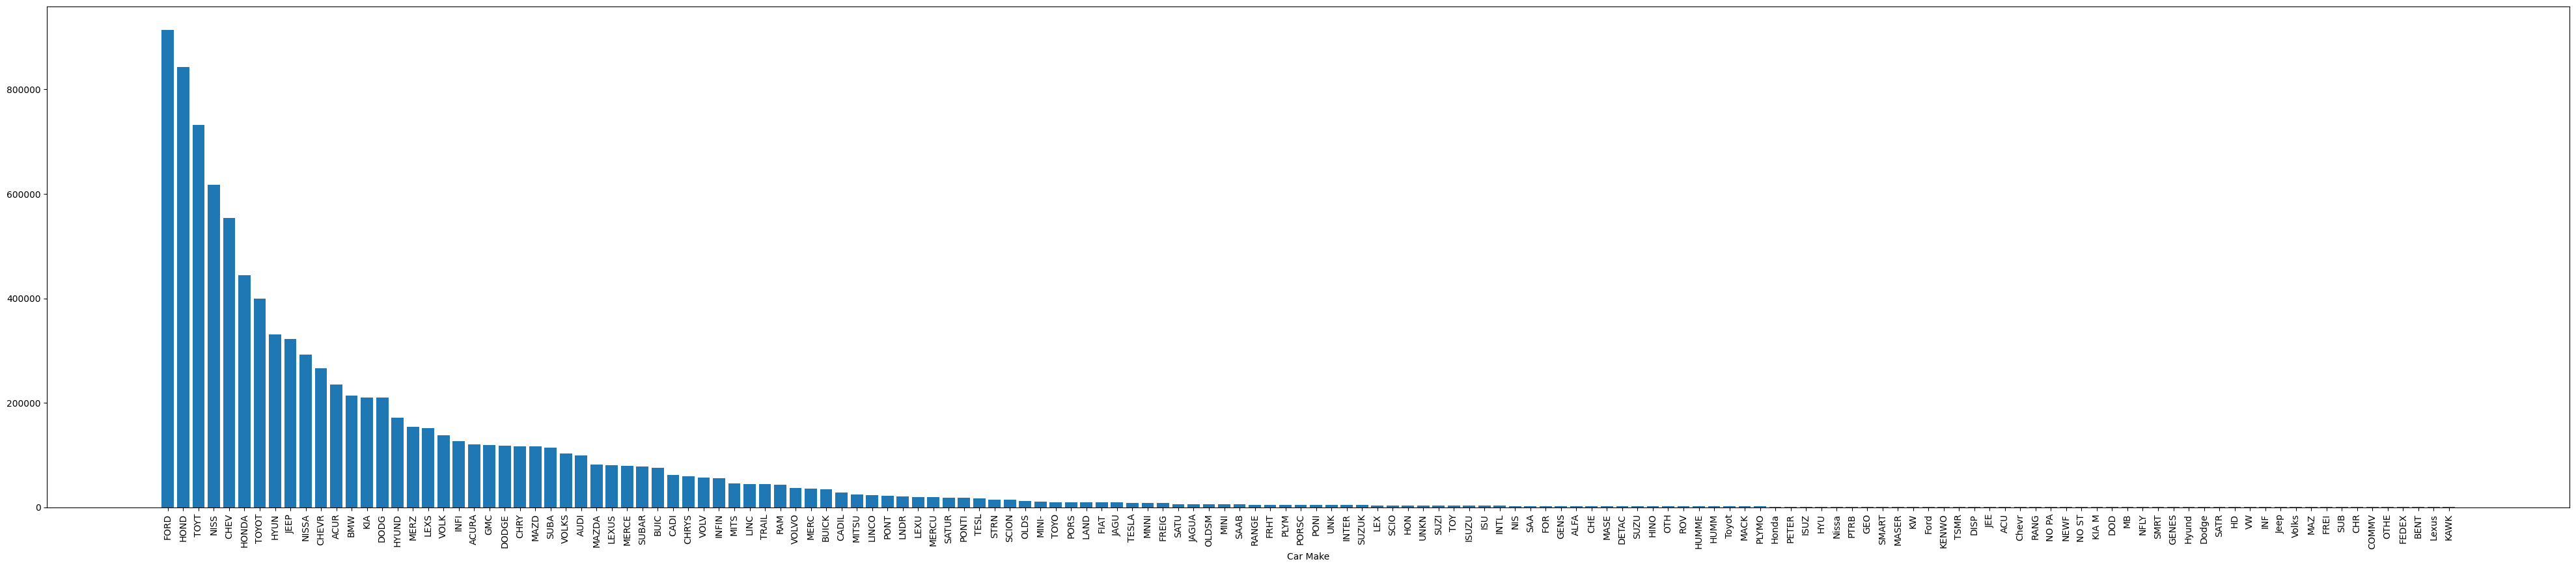

In [148]:
top_150_makes = df['Make'].value_counts().head(150).reset_index()
top_150_makes.columns = ['Make', 'Count']
plt.figure(figsize=(50, 10))
plt.bar(top_150_makes['Make'], top_150_makes['Count'])
plt.xticks(rotation=90)
plt.xlabel('Car Make')

In [149]:
# Step 1: Uppercase everything
df['Make_clean'] = df['Make'].str.upper().str.strip()

# Step 2: Comprehensive mapping
make_mapping = {
    # TOYOTA
    'TOYT': 'TOYOTA', 'TOYOT': 'TOYOTA', 'TOYO': 'TOYOTA', 'TOY': 'TOYOTA',
    'TOYA': 'TOYOTA', 'TOYTT': 'TOYOTA', 'TAOT': 'TOYOTA', 'TOTY': 'TOYOTA',
    'TYOT': 'TOYOTA', 'TOYP': 'TOYOTA', 'TOYY': 'TOYOTA', 'TOYTA': 'TOYOTA',
    'TOYT0': 'TOYOTA', 'TOYT9': 'TOYOTA', 'TAOTA': 'TOYOTA', 'TOYTD': 'TOYOTA',
    'TOYOC': 'TOYOTA',
    
    # HONDA
    'HOND': 'HONDA', 'HON': 'HONDA', 'HODNA': 'HONDA', 'HONA': 'HONDA',
    'HODA': 'HONDA', 'HOMD': 'HONDA', 'HOMDA': 'HONDA', 'HOND1': 'HONDA',
    'HOND.': 'HONDA', 'HOND`': 'HONDA', 'HHOND': 'HONDA', 'H0NDA': 'HONDA',
    'HONDN': 'HONDA', 'VHOND': 'HONDA', '.HOND': 'HONDA', '`HOND': 'HONDA',
    
    # NISSAN
    'NISS': 'NISSAN', 'NISSA': 'NISSAN', 'NIS': 'NISSAN', 'NISN': 'NISSAN',
    'NISS0': 'NISSAN', 'NISSI': 'NISSAN', 'NISAA': 'NISSAN', 'NISSN': 'NISSAN',
    'NISS4': 'NISSAN', 'NISS8': 'NISSAN', 'NIIS': 'NISSAN', 'NISA': 'NISSAN',
    ',NISS': 'NISSAN', '.NISS': 'NISSAN', 'NITS': 'NISSAN',
    
    # CHEVROLET
    'CHEV': 'CHEVROLET', 'CHEVR': 'CHEVROLET', 'CHE': 'CHEVROLET', 'CHEVY': 'CHEVROLET',
    'CHEVV': 'CHEVROLET', 'CHEV0': 'CHEVROLET', 'CHEV2': 'CHEVROLET', 'CHEVE': 'CHEVROLET',
    'CHEVS': 'CHEVROLET', 'CHVY': 'CHEVROLET', 'LCHEV': 'CHEVROLET', 'C4HEV': 'CHEVROLET',
    'CHE2V': 'CHEVROLET', 'CJEV': 'CHEVROLET',
    
    # HYUNDAI
    'HYUN': 'HYUNDAI', 'HYUND': 'HYUNDAI', 'HYU': 'HYUNDAI', 'HYN': 'HYUNDAI',
    'HYUN0': 'HYUNDAI', 'HYUN1': 'HYUNDAI', 'HYUN4': 'HYUNDAI', 'HYUN8': 'HYUNDAI',
    'HYND': 'HYUNDAI', 'HUYN': 'HYUNDAI', 'HYTUN': 'HYUNDAI', 'HYTR': 'HYUNDAI',
    
    # DODGE
    'DODG': 'DODGE', 'DOD': 'DODGE', 'DODG*': 'DODGE', 'DODG""': 'DODGE',
    'DODG`': 'DODGE', 'DOGD': 'DODGE', 'DOODG': 'DODGE', 'DODH': 'DODGE',
    'DOGE': 'DODGE',
    
    # MERCEDES
    'MERZ': 'MERCEDES', 'MERCE': 'MERCEDES', 'MERC': 'MERCEDES', 'MER': 'MERCEDES',
    'MB': 'MERCEDES', 'M B': 'MERCEDES', 'MEB': 'MERCEDES', 'BENZ': 'MERCEDES',
    'MB.': 'MERCEDES', 'MBZ': 'MERCEDES', 'MEBZ': 'MERCEDES', 'MEZ': 'MERCEDES',
    'MERB': 'MERCEDES', 'MERT': 'MERCEDES', 'MERX': 'MERCEDES', 'MERCY': 'MERCEDES',
    'MERZB': 'MERCEDES', 'MERZ4': 'MERCEDES', 'MEZC': 'MERCEDES', 'MEZR': 'MERCEDES',
    'MRZ': 'MERCEDES', 'M-B': 'MERCEDES', '`MB': 'MERCEDES', ',MERC': 'MERCEDES',
    'MREC': 'MERCEDES',
    
    # LEXUS
    'LEXS': 'LEXUS', 'LEXU': 'LEXUS', 'LEX': 'LEXUS', 'LEXI': 'LEXUS',
    'LEXU0': 'LEXUS', 'LEXY': 'LEXUS', 'LEXZ': 'LEXUS', 'LESU': 'LEXUS',
    'LEZU': 'LEXUS', 'LEUX': 'LEXUS', 'LEXSU': 'LEXUS', 'L,EXU': 'LEXUS',
    'LXU': 'LEXUS', 'LDXU': 'LEXUS', 'LEIK': 'LEXUS',
    
    # VOLKSWAGEN
    'VOLK': 'VOLKSWAGEN', 'VOLKS': 'VOLKSWAGEN', 'VW': 'VOLKSWAGEN', 'V W': 'VOLKSWAGEN',
    'VLK': 'VOLKSWAGEN', 'VW.': 'VOLKSWAGEN', 'VW\'': 'VOLKSWAGEN', 'VOLKW': 'VOLKSWAGEN',
    'VOLKP': 'VOLKSWAGEN', 'VOLK|': 'VOLKSWAGEN', 'VLW': 'VOLKSWAGEN', 'VILK': 'VOLKSWAGEN',
    'VLOK': 'VOLKSWAGEN', 'VOKS': 'VOLKSWAGEN', 'VV': 'VOLKSWAGEN',
    
    # ACURA
    'ACUR': 'ACURA', 'ACU': 'ACURA', 'AC': 'ACURA', 'ACR': 'ACURA',
    'ACUA': 'ACURA', 'ACUT': 'ACURA', 'ACURD': 'ACURA', 'ACUUR': 'ACURA',
    
    # INFINITI
    'INFI': 'INFINITI', 'INFIN': 'INFINITI', 'INF': 'INFINITI', 'INFN': 'INFINITI',
    'INFM': 'INFINITI', 'INIF': 'INFINITI', 'IFNI': 'INFINITI',
    
    # CHRYSLER
    'CHRY': 'CHRYSLER', 'CHRYS': 'CHRYSLER', 'CHR': 'CHRYSLER', 'CHYR': 'CHRYSLER',
    'CHRYB': 'CHRYSLER', 'CHYRS': 'CHRYSLER', 'CRYS': 'CHRYSLER', 'KRYS': 'CHRYSLER',
    
    # MAZDA
    'MAZD': 'MAZDA', 'MAZ': 'MAZDA', 'MADZ': 'MAZDA', 'MAZA': 'MAZDA',
    'MAZD0': 'MAZDA', 'MAZD`': 'MAZDA', 'MAZD7': 'MAZDA', 'MAZEA': 'MAZDA',
    'MAZAR': 'MAZDA', 'MAZAD': 'MAZDA', 'MAZY': 'MAZDA', 'MADA': 'MAZDA',
    'MAXDA': 'MAZDA', 'MAXD': 'MAZDA', 'MARD': 'MAZDA',
    
    # SUBARU
    'SUBA': 'SUBARU', 'SUBAR': 'SUBARU', 'SUB': 'SUBARU', 'SUBU': 'SUBARU',
    'SABAR': 'SUBARU', '1SUBA': 'SUBARU',
    
    # GMC
    'GMC.': 'GMC', 'GMC`': 'GMC', 'GMC/': 'GMC', 'GMC (': 'GMC',
    'GMC S': 'GMC', 'GMC T': 'GMC', 'GMC U': 'GMC', 'GMCL': 'GMC', 'GMCS': 'GMC',
    
    # BUICK
    'BUIC': 'BUICK', 'BUI': 'BUICK', 'BUCI': 'BUICK', 'BUIK': 'BUICK',
    'BUIX': 'BUICK', 'BUCK': 'BUICK',
    
    # CADILLAC
    'CADI': 'CADILLAC', 'CADIL': 'CADILLAC', 'CAD': 'CADILLAC', 'CADL': 'CADILLAC',
    'CADO': 'CADILLAC',
    
    # VOLVO
    'VOLV': 'VOLVO', 'VLV': 'VOLVO', 'VOL': 'VOLVO', 'VOLO': 'VOLVO',
    'VOLV0': 'VOLVO', 'VOLV4': 'VOLVO', 'VOVL': 'VOLVO', 'VOLW': 'VOLVO',
    'V0LVO': 'VOLVO', 'VOV': 'VOLVO',
    
    # MITSUBISHI
    'MITS': 'MITSUBISHI', 'MITSU': 'MITSUBISHI', 'MIT': 'MITSUBISHI',
    'MITI': 'MITSUBISHI', 'MITO': 'MITSUBISHI', 'MTTI': 'MITSUBISHI',
    
    # LINCOLN
    'LINC': 'LINCOLN', 'LINCO': 'LINCOLN', 'LIN': 'LINCOLN', 'LINC0': 'LINCOLN',
    'LINC3': 'LINCOLN', 'LINCI': 'LINCOLN', 'LINCL': 'LINCOLN', 'LINCN': 'LINCOLN',
    'LINCP': 'LINCOLN', 'LINOH': 'LINCOLN', 'LINVO': 'LINCOLN', 'LICON': 'LINCOLN',
    'LINCE': 'LINCOLN', 'LONCO': 'LINCOLN', 'LNC': 'LINCOLN',
    
    # PONTIAC
    'PONT': 'PONTIAC', 'PONTI': 'PONTIAC', 'PON': 'PONTIAC', 'PONI': 'PONTIAC',
    
    # SATURN
    'SATUR': 'SATURN', 'SATU': 'SATURN', 'SAT': 'SATURN', 'SATR': 'SATURN',
    'SATUN': 'SATURN', 'SATN': 'SATURN', 'STRN': 'SATURN', 'STR': 'SATURN',
    
    # TESLA
    'TESL': 'TESLA', 'TELSA': 'TESLA', 'TELS': 'TESLA', 'TES': 'TESLA',
    'TESIA': 'TESLA', 'TESL,': 'TESLA', 'TESLR': 'TESLA', 'TESLE': 'TESLA',
    'TUSLA': 'TESLA', 'TE5LR': 'TESLA', 'TSLA': 'TESLA', 'TSMR': 'TESLA',
    'TSM': 'TESLA',
    
    # FORD
    'FOR': 'FORD', 'FRD': 'FORD', 'FORD/': 'FORD', 'FORD-': 'FORD',
    'FORD,': 'FORD', 'FORD?': 'FORD', 'FORD0': 'FORD', 'FORD1': 'FORD',
    'FORD3': 'FORD', 'FORDF': 'FORD', 'FORDM': 'FORD', 'FORDT': 'FORD',
    'FORV': 'FORD', 'FFORD': 'FORD', 'FIRD': 'FORD', 'PFORD': 'FORD',
    'F0RD': 'FORD', 'PORD': 'FORD', '4FORD': 'FORD', 'FO': 'FORD',
    "' FOR": 'FORD', 'FOR3': 'FORD', 'FORE': 'FORD',
    
    # BMW
    'BMW.': 'BMW', 'BMW (': 'BMW', 'BMW 3': 'BMW', 'BMW 5': 'BMW',
    'BMW 7': 'BMW', 'BMW X': 'BMW', 'BMW/I': 'BMW', 'BMWU': 'BMW',
    'BMWYY': 'BMW', 'BMV': 'BMW', 'BMN': 'BMW', 'BNW': 'BMW',
    'BM': 'BMW', 'BWW': 'BMW', 'BW': 'BMW', 'DMW': 'BMW', 'MBW': 'BMW',
    
    # KIA
    'KIA M': 'KIA', 'KIA.': 'KIA', 'KIA02': 'KIA', 'KIA04': 'KIA',
    'KIA06': 'KIA', 'KIA N': 'KIA', 'KIA S': 'KIA', 'KIAD': 'KIA',
    'KIAY': 'KIA', 'KI': 'KIA',
    
    # JEEP
    'JEE': 'JEEP', 'JEP': 'JEEP', 'JEEE': 'JEEP', 'JEEPC': 'JEEP',
    'JEEPL': 'JEEP', 'JEEPS': 'JEEP', 'JEPP': 'JEEP', 'JEEP0': 'JEEP',
    'JP': 'JEEP',
    
    # AUDI
    'AUD': 'AUDI', 'AUDT': 'AUDI', 'AYDI': 'AUDI', 'AUID': 'AUDI',
    'AUOI': 'AUDI', 'AUDIO': 'AUDI', 'JAUDI': 'AUDI', 'AU': 'AUDI',
    'AUUR': 'AUDI', 'AUOR': 'AUDI',
    
    # LAND ROVER
    'LNDR': 'LAND ROVER', 'LAND': 'LAND ROVER', 'LANDR': 'LAND ROVER',
    'LANRO': 'LAND ROVER', 'LANR': 'LAND ROVER', 'LND': 'LAND ROVER',
    'LR': 'LAND ROVER', 'L R': 'LAND ROVER', 'LDRV': 'LAND ROVER',
    'LDRO': 'LAND ROVER', 'LNDRO': 'LAND ROVER', 'LNRO': 'LAND ROVER',
    'LRVR': 'LAND ROVER', 'LAN': 'LAND ROVER', 'RANGE': 'LAND ROVER',
    'RANG': 'LAND ROVER', 'ROVER': 'LAND ROVER', 'ROV': 'LAND ROVER',
    'RROV': 'LAND ROVER', 'RROVE': 'LAND ROVER', 'R ROV': 'LAND ROVER',
    'ROVR': 'LAND ROVER', 'ROVE': 'LAND ROVER', 'LANDO': 'LAND ROVER',
    'LANC': 'LAND ROVER', 'LANL': 'LAND ROVER', 'LR.': 'LAND ROVER',
    
    # JAGUAR
    'JAGU': 'JAGUAR', 'JAGUA': 'JAGUAR', 'JAG': 'JAGUAR', 'JAQU': 'JAGUAR',
    'JAQUA': 'JAGUAR', 'JAQUR': 'JAGUAR', 'JAGA': 'JAGUAR', 'JAGR': 'JAGUAR',
    'JAQ': 'JAGUAR',
    
    # PORSCHE
    'PORS': 'PORSCHE', 'PORSC': 'PORSCHE', 'POR': 'PORSCHE', 'PORSH': 'PORSCHE',
    'PORCH': 'PORSCHE', 'PORC': 'PORSCHE', 'PORE': 'PORSCHE', 'PORI': 'PORSCHE',
    'PORSE': 'PORSCHE', 'PORG': 'PORSCHE',
    
    # OLDSMOBILE
    'OLDS': 'OLDSMOBILE', 'OLDSM': 'OLDSMOBILE', 'OLD': 'OLDSMOBILE', '0LDS': 'OLDSMOBILE',
    
    # PLYMOUTH
    'PLYM': 'PLYMOUTH', 'PLYMO': 'PLYMOUTH', 'PLY': 'PLYMOUTH',
    
    # MERCURY
    'MERCU': 'MERCURY', 'MECUR': 'MERCURY', 'MERKU': 'MERCURY', 'MERK': 'MERCURY',
    
    # SCION
    'SCION': 'SCION', 'SCIO': 'SCION', 'SCI': 'SCION', 'SCIOM': 'SCION',
    'SCIUN': 'SCION', 'SICIO': 'SCION', 'SICON': 'SCION', 'SCLON': 'SCION',
    'SCON': 'SCION', 'SCOIN': 'SCION',
    
    # SAAB
    'SAAB': 'SAAB', 'SAA': 'SAAB', 'SABB': 'SAAB', 'SAB': 'SAAB', 'SAARI': 'SAAB',
    
    # MINI
    'MINI-': 'MINI', 'MNNI': 'MINI', 'MINI': 'MINI', 'MIN': 'MINI',
    'MNI': 'MINI', 'MINNI': 'MINI', 'MINIC': 'MINI', 'MINC': 'MINI',
    'MINI(': 'MINI', 'MINN': 'MINI', 'MINL': 'MINI', 'MIN C': 'MINI',
    
    # FIAT
    'FIAT': 'FIAT', 'FIA': 'FIAT', 'FAIT': 'FIAT', 'FLAT': 'FIAT', 'FALT': 'FIAT',
    
    # SUZUKI
    'SUZUK': 'SUZUKI', 'SUZU': 'SUZUKI', 'SUZI': 'SUZUKI', 'SUZ': 'SUZUKI',
    'SUZKI': 'SUZUKI', 'SUZK': 'SUZUKI', 'SUZIK': 'SUZUKI', 'SAZUK': 'SUZUKI',
    'SAZU': 'SUZUKI', 'SUKUZ': 'SUZUKI', 'SUZUI': 'SUZUKI', 'SUZX': 'SUZUKI',
    'SUSK': 'SUZUKI',
    
    # ISUZU
    'ISUZU': 'ISUZU', 'ISU': 'ISUZU', 'ISUZ': 'ISUZU', 'ISZU': 'ISUZU',
    'ISUS': 'ISUZU', 'IZUZU': 'ISUZU', 'IZUZ': 'ISUZU', 'IEUZ': 'ISUZU',
    
    # HUMMER
    'HUMME': 'HUMMER', 'HUMM': 'HUMMER', 'HUM': 'HUMMER', 'HUMMU': 'HUMMER',
    'HUMMR': 'HUMMER', 'HUMM2': 'HUMMER',
    
    # RAM
    'RAM': 'RAM', 'RAM T': 'RAM', 'RAM (': 'RAM', 'RAM.': 'RAM',
    'RAM41': 'RAM', 'RAM25': 'RAM', 'RAM 2': 'RAM', 'RAMS': 'RAM',
    
    # DAEWOO
    'DAEWO': 'DAEWOO', 'DAEW': 'DAEWOO', 'DAEW0': 'DAEWOO', 'DAE': 'DAEWOO',
    'DAWOO': 'DAEWOO', 'DAIX': 'DAEWOO',
    
    # MASERATI
    'MASE': 'MASERATI', 'MASER': 'MASERATI', 'MASAR': 'MASERATI', 'MASRA': 'MASERATI',
    'MASUR': 'MASERATI', 'MAS': 'MASERATI',
    
    # BENTLEY
    'BENT': 'BENTLEY', 'BENTL': 'BENTLEY', 'BEN': 'BENTLEY',
    
    # FERRARI
    'FERR': 'FERRARI', 'FERRA': 'FERRARI', 'FERI': 'FERRARI',
    
    # LAMBORGHINI
    'LAMO': 'LAMBORGHINI', 'LAMBO': 'LAMBORGHINI', 'LMBO': 'LAMBORGHINI',
    
    # ALFA ROMEO
    'ALFA': 'ALFA ROMEO', 'ALF': 'ALFA ROMEO', 'ALPHA': 'ALFA ROMEO',
    'ALFAR': 'ALFA ROMEO', 'ABART': 'ALFA ROMEO', 'A LF0': 'ALFA ROMEO',
    
    # GENESIS
    'GENS': 'GENESIS', 'GENES': 'GENESIS', 'GENE': 'GENESIS', 'GENSI': 'GENESIS',
    'GENIS': 'GENESIS', 'GENER': 'GENESIS', 'GNSI': 'GENESIS', 'GNESI': 'GENESIS',
    'GEN': 'GENESIS',
    
    # SMART
    'SMART': 'SMART', 'SMRT': 'SMART', 'SMAR': 'SMART',
    
    # GEO
    'GEO': 'GEO',
    
    # EAGLE
    'EAGLE': 'EAGLE', 'EAGL': 'EAGLE', 'EAG': 'EAGLE', 'EAGEL': 'EAGLE',
    'EAGE': 'EAGLE', 'EAGR': 'EAGLE',
    
    # LUCID
    'LUCD': 'LUCID', 'LUCID': 'LUCID', 'LUCI': 'LUCID',
    
    # RIVIAN
    'RIVIA': 'RIVIAN', 'RIVA': 'RIVIAN', 'RIV': 'RIVIAN', 'RIVEA': 'RIVIAN',
    
    # POLESTAR
    'POLA': 'POLESTAR', 'POLE': 'POLESTAR', 'POLAR': 'POLESTAR', 'POLES': 'POLESTAR',
}

df['Make_clean'] = df['Make_clean'].map(make_mapping).fillna(df['Make_clean'])

# Step 3: Anything not in a known make → OTHER
known_makes = set(make_mapping.values()) | {'FORD', 'HONDA', 'TOYOTA', 'NISSAN', 'CHEVROLET',
    'HYUNDAI', 'JEEP', 'BMW', 'KIA', 'DODGE', 'MERCEDES', 'LEXUS', 'VOLKSWAGEN',
    'ACURA', 'INFINITI', 'GMC', 'CHRYSLER', 'MAZDA', 'SUBARU', 'AUDI', 'BUICK',
    'CADILLAC', 'VOLVO', 'MITSUBISHI', 'LINCOLN', 'PONTIAC', 'SATURN', 'TESLA',
    'OLDSMOBILE', 'PLYMOUTH', 'MERCURY', 'SCION', 'SAAB', 'MINI', 'FIAT',
    'PORSCHE', 'JAGUAR', 'LAND ROVER', 'SUZUKI', 'ISUZU', 'HUMMER', 'RAM',
    'DAEWOO', 'MASERATI', 'BENTLEY', 'FERRARI', 'LAMBORGHINI', 'ALFA ROMEO',
    'GENESIS', 'SMART', 'GEO', 'EAGLE', 'LUCID', 'RIVIAN', 'POLESTAR'}

df.loc[~df['Make_clean'].isin(known_makes), 'Make_clean'] = 'OTHER'

print(df['Make_clean'].value_counts().head(30))
print(f"\nUnique makes: {df['Make_clean'].nunique()}")

Make_clean
HONDA         1290808
TOYOTA        1145452
FORD           916697
NISSAN         912885
CHEVROLET      823511
HYUNDAI        503400
ACURA          355826
DODGE          329448
JEEP           323828
MERCEDES       269951
LEXUS          255089
VOLKSWAGEN     242374
BMW            214381
KIA            211284
MAZDA          198536
SUBARU         191909
INFINITI       182786
CHRYSLER       177008
GMC            119046
BUICK          110073
OTHER          109318
AUDI           100104
VOLVO           93548
CADILLAC        90638
MITSUBISHI      70777
LINCOLN         68337
PONTIAC         44675
RAM             43119
SATURN          39156
LAND ROVER      37851
Name: count, dtype: int64

Unique makes: 56


In [150]:
luxury = ['BMW', 'MERCEDES', 'LEXUS', 'AUDI', 'ACURA', 'INFINITI', 'VOLVO',
          'CADILLAC', 'LINCOLN', 'LAND ROVER', 'JAGUAR', 'PORSCHE', 'MASERATI',
          'BENTLEY', 'FERRARI', 'LAMBORGHINI', 'ALFA ROMEO', 'LUCID', 'RIVIAN',
          'POLESTAR', 'TESLA']

mid_range = ['TOYOTA', 'HONDA', 'FORD', 'NISSAN', 'CHEVROLET', 'HYUNDAI',
             'DODGE', 'JEEP', 'VOLKSWAGEN', 'KIA', 'MAZDA', 'SUBARU',
             'CHRYSLER', 'GMC', 'BUICK', 'MITSUBISHI', 'PONTIAC', 'RAM',
             'SATURN', 'GENESIS', 'SMART', 'GEO', 'EAGLE', 'MINI', 'FIAT']

economy = ['OLDSMOBILE', 'PLYMOUTH', 'MERCURY', 'SCION', 'SAAB', 'SUZUKI',
           'ISUZU', 'HUMMER', 'DAEWOO']

df['Tier'] = df['Make_clean'].apply(
    lambda x: 'Luxury' if x in luxury
    else ('Mid-Range' if x in mid_range
    else ('Economy/Discontinued' if x in economy
    else 'Other/Unknown')))

print(df['Tier'].value_counts())
print('\n--- Avg citations per tier ---')
print(df.groupby('Tier')['Tag'].value_counts().groupby('Tier').describe())

Tier
Mid-Range               7733505
Luxury                  1729338
Other/Unknown            109318
Economy/Discontinued      86631
Name: count, dtype: int64

--- Avg citations per tier ---
                          count      mean       std  min  25%  50%  75%    max
Tier                                                                          
Economy/Discontinued    36472.0  2.374945  3.354596  1.0  1.0  1.0  2.0   99.0
Luxury                 490585.0  3.524902  5.891875  1.0  1.0  2.0  4.0  470.0
Mid-Range             2262329.0  3.418262  5.614779  1.0  1.0  2.0  3.0  909.0
Other/Unknown           53117.0  2.057948  4.466604  1.0  1.0  1.0  2.0  192.0


In [151]:
print(df.head(10))

   Citation       Tag ExpMM ExpYY State   Make  ViolCode  \
0        91    03W671    08    10    MD   FORD        27   
1       166  T294093T    12    11    MD   JEEP        12   
2       299  19TLR318    02    13    ME    NaN        99   
3       315  14TLR551    11    14    ME    NaN        99   
4       562   9AE2340    03    13    MD   SUZU        18   
5       653   SG23690    12    99    MD   CHEV         5   
6       703   7AB5707    10    12    MD   NISS        27   
7       711   3AG8711    04    12    MD  ACURA        27   
8       729   6AD5111    01    13    MD   NISS        27   
9      1016   93475CD    03    12    MD  ACURA        27   

                                Description  ViolFine                ViolDate  \
0              No Stop/Park Street Cleaning        52   12/9/2011 11:55:00 AM   
1    No Stopping/Standing Not Tow-Away Zone        32   12/9/2011 12:39:00 PM   
2  All Other Stopping or Parking Violations        32   12/9/2011 11:55:00 AM   
3  All Other St

In [152]:
df['ViolDate'] = pd.to_datetime(df['ViolDate'])
df['PenaltyDate'] = pd.to_datetime(df['PenaltyDate'], errors='coerce')
df['NoticeDate'] = pd.to_datetime(df['NoticeDate'], errors='coerce')


/var/folders/my/scqy6lj505v835sl0q7yr68m0000gn/T/ipykernel_82073/945578808.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['NoticeDate'] = pd.to_datetime(df['NoticeDate'], errors='coerce')


In [153]:
df['ViolDate'] = pd.to_datetime(df['ViolDate'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['PenaltyDate'] = pd.to_datetime(df['PenaltyDate'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['NoticeDate'] = pd.to_datetime(df['NoticeDate'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [154]:
df = df[df['isDeleted'] != 1.0]

print(df.shape)
print(df[['Balance', 'OpenFine', 'OpenPenalty', 'ViolFine']].describe().round(2))

(9658792, 24)
          Balance    OpenFine  OpenPenalty    ViolFine
count  9658792.00  9658792.00   9658792.00  9658792.00
mean        29.62       17.24        15.60       49.98
std         92.04       33.86        78.66       35.56
min          0.00        0.00         0.00        0.00
25%          0.00        0.00         0.00       40.00
50%          0.00        0.00         0.00       40.00
75%         40.00       32.00         0.00       52.00
max       2912.00      502.00      2768.00      502.00


In [155]:
df['is_unpaid'] = df['Balance'] > 0

print(df['is_unpaid'].value_counts())
print(f"Total unpaid balance: ${df.loc[df['is_unpaid'], 'Balance'].sum():,.2f}")

is_unpaid
False    6833825
True     2824967
Name: count, dtype: int64
Total unpaid balance: $286,117,139.00


In [156]:

neighborhood = (df[df['is_unpaid']]
    .groupby('Neighborhood')
    .agg(
        total_unpaid=('Balance', 'sum'),
        num_citations=('Balance', 'count'),
        avg_balance=('Balance', 'mean')
    )
    .sort_values('total_unpaid', ascending=False)
)

print(neighborhood.head(15))

                                 total_unpaid  num_citations  avg_balance
Neighborhood                                                             
Downtown                              1611662           9696   166.219266
Belair-Edison                         1597796           6557   243.677901
Federal Hill                          1545418           7266   212.691715
Coldstream Homestead Montebello       1495141           5673   263.553852
Reservoir Hill                        1351297           5532   244.269161
Fells Point                           1142888           7551   151.355847
East Baltimore Midway                  869836           3570   243.651541
Mount Vernon                           816615           5196   157.162240
Washington Village/Pigtown             797577           3044   262.016097
Highlandtown                           760893           3494   217.771322
Upton                                  741536           3029   244.812149
Barclay                               

In [157]:
violation = (df[df['is_unpaid']]
    .groupby(['ViolCode', 'Description'])
    .agg(
        total_unpaid=('Balance', 'sum'),
        num_citations=('Balance', 'count'),
        avg_balance=('Balance', 'mean')
    )
    .sort_values('total_unpaid', ascending=False)
)

print(violation.head(10))

                                                 total_unpaid  num_citations  \
ViolCode Description                                                           
32       Fixed Speed Camera                          43071706        1074106   
27       No Stop/Park Street Cleaning                35420350         153996   
22       Expired Tags                                34504128         213180   
18       All Other Parking Meter Violations          30922186         212504   
30       Red Light Violation                         27462640         365830   
8        No Stopping/Standing Tow Away Zone          17805097          85913   
1        Abandonded Vehicle                          13198142          23389   
12       No Stopping/Standing Not Tow-Away Zone      12944421          97260   
31       Right on Red                                11241553         149772   
11       Residential Parking Permit Only             10358808          50525   

                                       

In [158]:
state = (df[df['is_unpaid']]
    .groupby('State')
    .agg(
        total_unpaid=('Balance', 'sum'),
        num_citations=('Balance', 'count'),
        avg_balance=('Balance', 'mean')
    )
    .sort_values('total_unpaid', ascending=False)
)

# MD vs out-of-state comparison
md_balance = state.loc['MD', 'total_unpaid'] if 'MD' in state.index else 0
oos_balance = state.drop('MD', errors='ignore')['total_unpaid'].sum()
print(f"MD unpaid: ${md_balance:,.2f}")
print(f"Out-of-state unpaid: ${oos_balance:,.2f}")
print(state.head(10))

MD unpaid: $224,546,818.00
Out-of-state unpaid: $61,570,289.00
       total_unpaid  num_citations  avg_balance
State                                          
MD        224546818        2072343   108.354079
VA         25310454         334413    75.686214
PA          6857008         116297    58.961177
NC          3147380          29344   107.258043
NJ          2457035          28164    87.240271
FL          2252190          22218   101.367810
DE          2041990          23206    87.994053
TX          1902253          20793    91.485259
NY          1901130          20263    93.822731
DC          1695851          20729    81.810555


In [159]:
tier = (df[df['is_unpaid']]
    .groupby('Tier')
    .agg(
        total_unpaid=('Balance', 'sum'),
        num_citations=('Balance', 'count'),
        avg_balance=('Balance', 'mean')
    )
    .sort_values('total_unpaid', ascending=False)
)

print(tier)

                      total_unpaid  num_citations  avg_balance
Tier                                                          
Mid-Range                215414809        2150488   100.170198
Luxury                    58481284         599276    97.586561
Economy/Discontinued       6212529          37900   163.918971
Other/Unknown              6008517          37303   161.073292


In [160]:
collection = (df.groupby('Neighborhood')
    .agg(
        total_fines=('ViolFine', 'sum'),
        total_unpaid=('Balance', 'sum')
    )
)
collection['collection_rate'] = 1 - (collection['total_unpaid'] / collection['total_fines'])
collection = collection.sort_values('collection_rate', ascending=True)

# Worst collection rates
print(collection.head(15))

                                 total_fines  total_unpaid  collection_rate
Neighborhood                                                               
Sabina-Mattfeldt                          64           357        -4.578125
Orangeville Industrial Area             4362         19183        -3.397753
Gay Street                             30708        113025        -2.680637
LOYOLA/NOTRE DAME                         52           173        -2.326923
Seton Business Park                      720          2357        -2.273611
Saint Josephs                          17539         54955        -2.133303
Ten Hills                                836          2484        -1.971292
Madison-Eastend                        34246        101636        -1.967821
Franklin Square                        38834        114830        -1.956945
GARWYN OAKS                              590          1730        -1.932203
Penrose/Fayette Street Outreach        81820        234169        -1.862002
Lower Edmond

In [161]:
collection['penalty_multiplier'] = collection['total_unpaid'] / collection['total_fines']
collection = collection.sort_values('penalty_multiplier', ascending=False)
print(collection.head(15))

                                 total_fines  total_unpaid  collection_rate  \
Neighborhood                                                                  
Sabina-Mattfeldt                          64           357        -4.578125   
Orangeville Industrial Area             4362         19183        -3.397753   
Gay Street                             30708        113025        -2.680637   
LOYOLA/NOTRE DAME                         52           173        -2.326923   
Seton Business Park                      720          2357        -2.273611   
Saint Josephs                          17539         54955        -2.133303   
Ten Hills                                836          2484        -1.971292   
Madison-Eastend                        34246        101636        -1.967821   
Franklin Square                        38834        114830        -1.956945   
GARWYN OAKS                              590          1730        -1.932203   
Penrose/Fayette Street Outreach        81820        

In [163]:
!pip3.14 install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [164]:
import seaborn as sns

In [165]:
top_viols = violation.head(5).index.get_level_values('Description')
top_hoods = neighborhood.head(10).index

unpaid = df[df['is_unpaid']].copy()

cross = (unpaid[unpaid['Description'].isin(top_viols) & 
               unpaid['Neighborhood'].isin(top_hoods)]
    .pivot_table(values='Balance', index='Neighborhood', 
                 columns='Description', aggfunc='sum', fill_value=0)                 
)
print(cross)

Description                      All Other Parking Meter Violations  \
Neighborhood                                                          
Belair-Edison                                                   604   
Coldstream Homestead Montebello                                 551   
Downtown                                                     740650   
East Baltimore Midway                                           389   
Federal Hill                                                 451556   
Fells Point                                                  631333   
Highlandtown                                                 284384   
Mount Vernon                                                 378248   
Reservoir Hill                                                  744   
Washington Village/Pigtown                                    11382   

Description                      Expired Tags  No Stop/Park Street Cleaning  
Neighborhood                                                         

In [166]:
cross_tier = (unpaid[unpaid['Description'].isin(top_viols)]
    .pivot_table(values='Balance', index='Tier', 
                 columns='Description', aggfunc='sum', fill_value=0)
)
print(cross_tier)

Description           All Other Parking Meter Violations  Expired Tags  \
Tier                                                                     
Economy/Discontinued                              726777       1144089   
Luxury                                           6575059       7169891   
Mid-Range                                       23457562      25719009   
Other/Unknown                                     162788        471139   

Description           Fixed Speed Camera  No Stop/Park Street Cleaning  \
Tier                                                                     
Economy/Discontinued              255768                       1290082   
Luxury                           9289784                       7028851   
Mid-Range                       33465271                      26901883   
Other/Unknown                      60883                        199534   

Description           Red Light Violation  
Tier                                       
Economy/Discontinued  

In [167]:
cross_hood_tier = (unpaid[unpaid['Neighborhood'].isin(top_hoods)]
    .pivot_table(values='Balance', index='Neighborhood', 
                 columns='Tier', aggfunc='sum', fill_value=0)
)
print(cross_hood_tier)

Tier                             Economy/Discontinued  Luxury  Mid-Range  \
Neighborhood                                                               
Belair-Edison                                   59897  338666    1183728   
Coldstream Homestead Montebello                 52074  309266    1122664   
Downtown                                        45970  348895    1186660   
East Baltimore Midway                           33799  174352     651276   
Federal Hill                                    33172  367522    1137538   
Fells Point                                     29579  232572     868232   
Highlandtown                                    15329  123557     619807   
Mount Vernon                                    19416  165969     627129   
Reservoir Hill                                  43740  315841     976739   
Washington Village/Pigtown                      32682  163775     584102   

Tier                             Other/Unknown  
Neighborhood                          

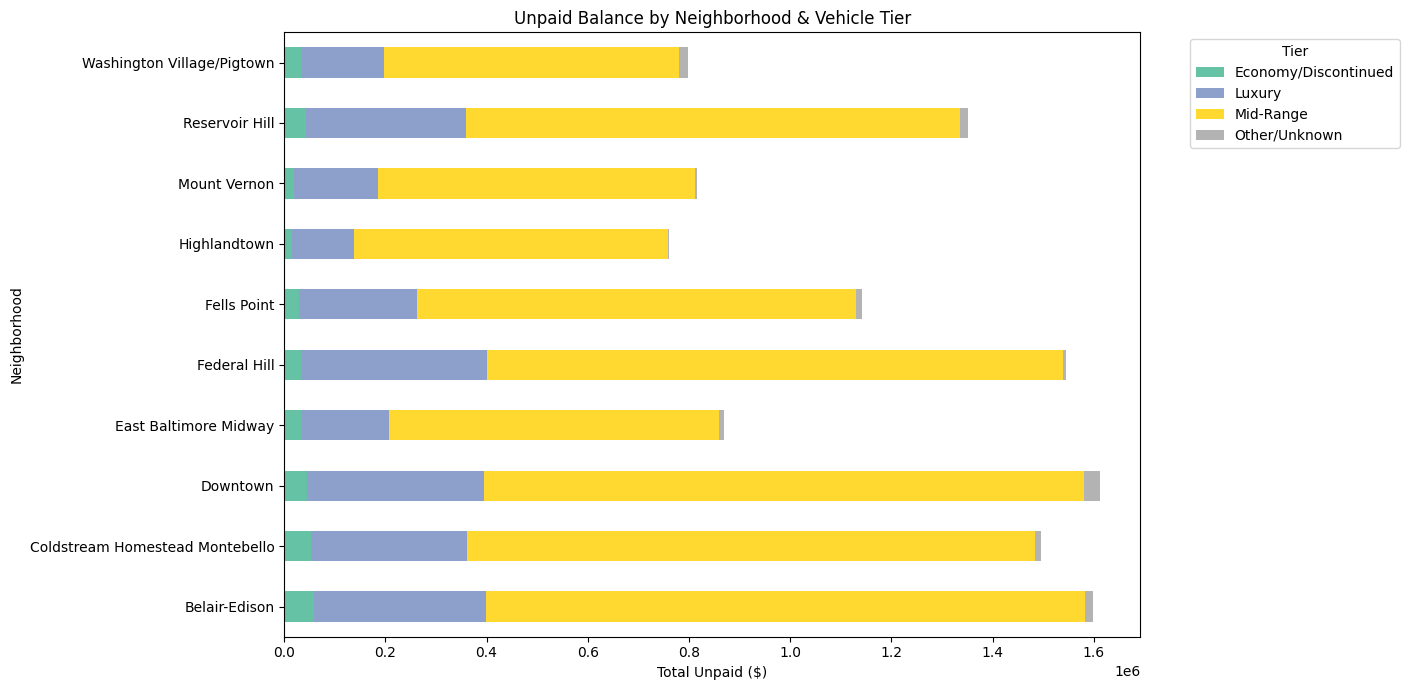

In [168]:
cross_hood_tier.plot(kind='barh', stacked=True, figsize=(12,7), 
                     colormap='Set2')
plt.title('Unpaid Balance by Neighborhood & Vehicle Tier')
plt.xlabel('Total Unpaid ($)')
plt.legend(title='Tier', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('hood_tier_stacked.png', dpi=150)
plt.show()

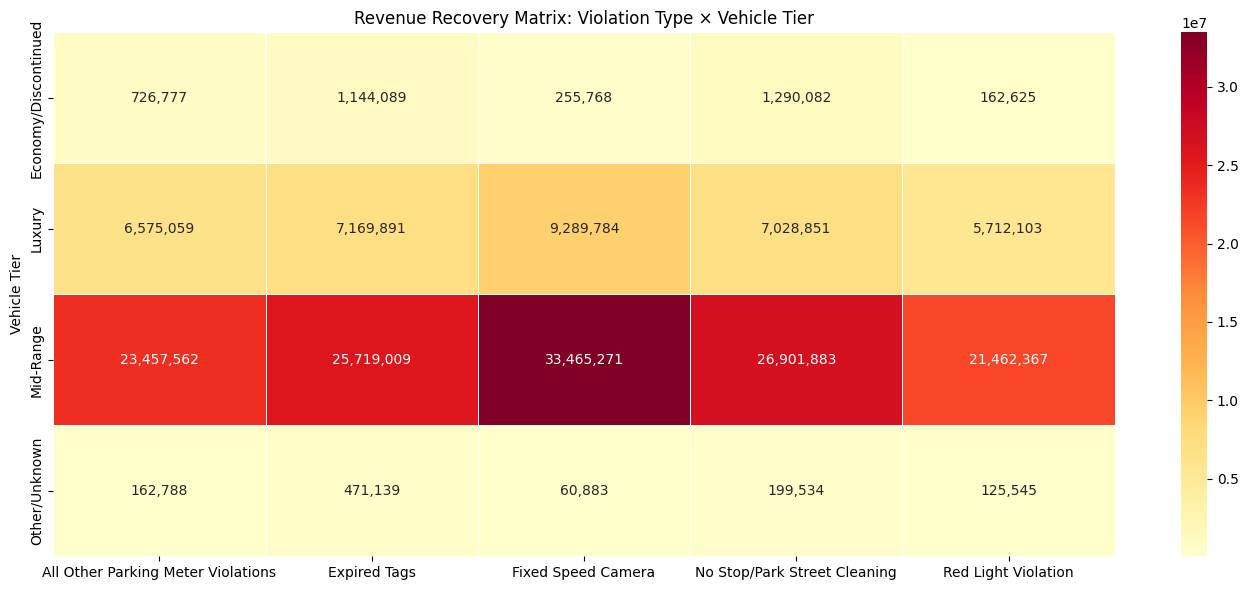

In [169]:
plt.figure(figsize=(14,6))
sns.heatmap(cross_tier, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue Recovery Matrix: Violation Type × Vehicle Tier')
plt.ylabel('Vehicle Tier')
plt.xlabel('')
plt.tight_layout()
plt.savefig('revenue_matrix.png', dpi=150)
plt.show()